In [1]:
import cv2
import torch
import json

import os
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../external/facechain'))
from constants import BASE_DIR
# from utils import show_images
from tqdm.auto import tqdm

In [2]:
from facechain.constants import neg_prompt, pos_prompt_with_cloth, pos_prompt_with_style, base_models

styles = []
for base_model in base_models:
    style_in_base = []
    folder_path = f"../../external/facechain/styles/{base_model['name']}"
    files = os.listdir(folder_path)
    files.sort()
    for file in files:
        file_path = os.path.join(folder_path, file)
        with open(file_path, "r") as f:
            data = json.load(f)
            style_in_base.append(data['name'])
            styles.append(data)
    base_model['style_list'] = style_in_base

In [9]:
styles[22]

{'name': '西部牛仔风(Cowboy style)',
 'img': './style_image/Cowboy.jpg',
 'model_id': 'houpeiran/mymodel',
 'revision': 'v1.0.0',
 'bin_file': 'style_niuzai768.safetensors',
 'multiplier_style': 0.7,
 'multiplier_human': 0.95,
 'add_prompt_style': 'western cowboy style,photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair'}

In [17]:
# Copyright (c) Alibaba, Inc. and its affiliates.
import os
import json
import cv2
from facechain.inference_fact import GenPortrait
from facechain.utils import snapshot_download


def generate_pos_prompt(style_model, prompt_cloth):
    if style_model is not None:
        matched = list(filter(lambda style: style_model == style['name'], styles))
        if len(matched) == 0:
            raise ValueError(f'styles not found: {style_model}')
        matched = matched[0]
        if matched['model_id'] is None:
            pos_prompt = pos_prompt_with_cloth.format(prompt_cloth)
        else:
            pos_prompt = pos_prompt_with_style.format(matched['add_prompt_style'])
    else:
        pos_prompt = pos_prompt_with_cloth.format(prompt_cloth)
    return pos_prompt



use_pose_model = True
input_img_path = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned_focused/Frame 27.png'
pose_image = BASE_DIR / 'datasets/celebrities/mo_salah/cleaned_focused/Frame 8.png'
num_generate = 1
multiplier_style = 0.7
output_dir = './generated'
base_model_idx = 1
style_idx = 22

base_model = base_models[base_model_idx]
style = styles[style_idx]
model_id = style['model_id']

if model_id == None:
    style_model_path = None
    pos_prompt = generate_pos_prompt(style['name'], style['add_prompt_style'])
else:
    if os.path.exists(model_id):
        model_dir = model_id
    else:
        model_dir = snapshot_download(model_id, revision=style['revision'])
    style_model_path = os.path.join(model_dir, style['bin_file'])
    pos_prompt = generate_pos_prompt(style['name'], style['add_prompt_style'])  # style has its own prompt

if not use_pose_model:
    pose_image = None


# outputs = gen_portrait(num_generate, base_model_idx, style_model_path, pos_prompt, neg_prompt, input_img_path, pose_image, multiplier_style)

# os.makedirs(output_dir, exist_ok=True)

# for i, out_tmp in enumerate(outputs):
#     cv2.imwrite(os.path.join(output_dir, f'{i}.png'), out_tmp)



2025-06-19 03:11:52,799 - modelscope - INFO - Use user-specified model revision: v1.0.0


In [5]:
from facechain.inference_fact import GenPortrait

gen_portrait = GenPortrait()

2025-06-19 02:40:14,097 - modelscope - INFO - Use user-specified model revision: v1.0.1
2025-06-19 02:40:29,992 - modelscope - INFO - Use user-specified model revision: v1.0.1


2025-06-19 02:40:35,876 - modelscope - INFO - Use user-specified model revision: v1.0.1
/opt/conda/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
2025-06-19 02:40:43,675 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/models/damo/cv_resnet101_image-multiple-human-parsing
2025-06-19 02:40:43,677 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/models/damo/cv_resnet101_image-multiple-human-parsing.
2025-06-19 02:40:43,687 - modelscope - INFO - initialize model from /mnt/workspace/.cache/modelscope/models/damo/cv_resnet101_image-multiple-human-parsing
2025-06-19 02:40:44

2025-06-19 02:40:56,597 - modelscope - INFO - Use user-specified model revision: v1.0.3
2025-06-19 02:40:57,833 - modelscope - WARNING - Use allow_remote=True. Will invoke codes from /mnt/workspace/.cache/modelscope/models/damo/cv_unet_face_fusion_torch. Please make sure that you can trust the external codes.
2025-06-19 02:40:57,984 - modelscope - WARNING - ('PIPELINES', 'face_fusion_torch', 'face_fusion_torch') not found in ast index file
2025-06-19 02:40:57,985 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/models/damo/cv_unet_face_fusion_torch
2025-06-19 02:40:57,985 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/models/damo/cv_unet_face_fusion_torch.
2025-06-19 02:40:57,988 - modelscope - INFO - initialize model from /mnt/workspace/.cache/modelscope/models/damo/cv_unet_face_fusion_torch
2025-06-19 02:40:57,991 - modelscope - WARNING - Use allow_remote=True. Will invoke codes from /mnt/workspace/.cache/modelscope/model

2025-06-19 02:41:06,615 - modelscope - WARNING - Model revision not specified, use revision: v1.1
2025-06-19 02:41:07,563 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
2025-06-19 02:41:07,564 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd.
2025-06-19 02:41:07,567 - modelscope - INFO - initialize model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
/opt/conda/lib/python3.8/site-packages/mmdet/models/dense_heads/anchor_head.py:116: UserWarning: DeprecationWarning: `num_anchors` is deprecated, for consistency or also use `num_base_priors` instead
  warnings.warn('DeprecationWarning: `num_anchors` is deprecated, '
/opt/conda/lib/python3.8/site-packages/mmdet/models/dense_heads/anchor_head.py:123: UserWarning: DeprecationWarning: anchor_generator is deprecated, please use "prior_generato

load checkpoint from local path: /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd/pytorch_model.pt


...

load checkpoint from local path: /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd/pytorch_model.pt


2025-06-19 02:43:48,291 - modelscope - INFO - load model done


2025-06-19 02:43:50,831 - modelscope - INFO - Use user-specified model revision: v1.0.0


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not e

In [19]:
num_generate, base_model_idx, style_model_path, pos_prompt, neg_prompt, str(input_img_path), str(pose_image), multiplier_style

(1,
 1,
 '/mnt/workspace/.cache/modelscope/models/houpeiran/mymodel/style_niuzai768.safetensors',
 'western cowboy style,photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair, upper_body, raw photo, masterpiece, solo, medium shot, high detail face, photorealistic, best quality',
 '(nsfw:2), paintings, sketches, (worst quality:2), (low quality:2), lowers, normal quality, ((monochrome)), ((grayscale)), logo, word, character, bad hand, tattoo, (username, watermark, signature, time signature, timestamp, artist name, copyright name, copyright),low res, ((monochrome)), ((grayscale)), skin spots, acnes, skin blemishes, age spot, glans, extra fingers, fewer fingers, strange fingers, bad hand, mole, ((extra legs)), ((extra hands))',
 '/app/datasets/celebrities/mo_salah/cleaned_focused/Frame 27.png',
 '/app/datasets/celebrities/mo_salah/cleaned_focused/Frame 8.png',
 0.7)

In [21]:
??gen_portrait

Signature:  
gen_portrait(
    use_face_swap,
    num_gen_images=1,
    base_model_idx=0,
    style_model_path=None,
    pos_prompt='',
    neg_prompt='',
    input_img_path=None,
    pose_image=None,
    multiplier_style=0,
)
Type:        GenPortrait
String form: <facechain.inference_fact.GenPortrait object at 0x7f34042082e0>
File:        /app/external/facechain/facechain/inference_fact.py
Source:     
class GenPortrait:

    def __init__(self):
        dtype = torch.float16
        
        pose_model_id = 'damo/face_chain_control_model'
        pose_revision = 'v1.0.1'
        pose_file = 'model_controlnet/control_v11p_sd15_openpose'
        pose_model_path = os.path.join(
            snapshot_download(pose_model_id, revision=pose_revision),
            pose_file)
        
        self.controlnet = ControlNetModel.from_pretrained(pose_model_path, torch_dtype=torch.float16)

        self.segmentation_pipeline = pipeline(
            Tasks.image_segmentation,
            'damo/cv_resn

In [35]:
pos_prompt

'western cowboy style,photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair, upper_body, raw photo, masterpiece, solo, medium shot, high detail face, photorealistic, best quality'

In [36]:
outputs = gen_portrait(1, num_generate, base_model_idx, None, "photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair, upper_body, raw photo, masterpiece, solo, medium shot, high detail face, photorealistic, best quality'", neg_prompt, str(input_img_path), str(pose_image), 0)

2025-06-19 03:28:03,787 - modelscope - INFO - Use user-specified model revision: v1.0.0
2025-06-19 03:28:04,300 - modelscope - INFO - Got 2 files, start to download ...


Processing 2 items:   0%|          | 0.00/2.00 [00:00<?, ?it/s]

2025-06-19 03:29:16,989 - modelscope - INFO - Download model 'Cherrytest/zjz_mj_jiyi_small_addtxt_fromleo' successfully.


pose_control_weight 1.0
depth_control_weight 0.0
pos_prompt a handsome man, 35-year-old, photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair, upper_body, raw photo, masterpiece, solo, medium shot, high detail face, photorealistic, best quality'
use_face_pose True
(512, 512)
["a handsome man, 35-year-old, photography,best quality, realistic, photorealistic, intricate details, cinematic light,  clear line, ultra high res, short hair, upper_body, raw photo, masterpiece, solo, medium shot, high detail face, photorealistic, best quality'"] ['(nsfw:2), paintings, sketches, (worst quality:2), (low quality:2), lowers, normal quality, ((monochrome)), ((grayscale)), logo, word, character, bad hand, tattoo, (username, watermark, signature, time signature, timestamp, artist name, copyright name, copyright),low res, ((monochrome)), ((grayscale)), skin spots, acnes, skin blemishes, age spot, glans, extra fingers, fewer fing

  0%|          | 0/50 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

In [38]:
# Image.open(str(input_img_path)).convert('RGB')

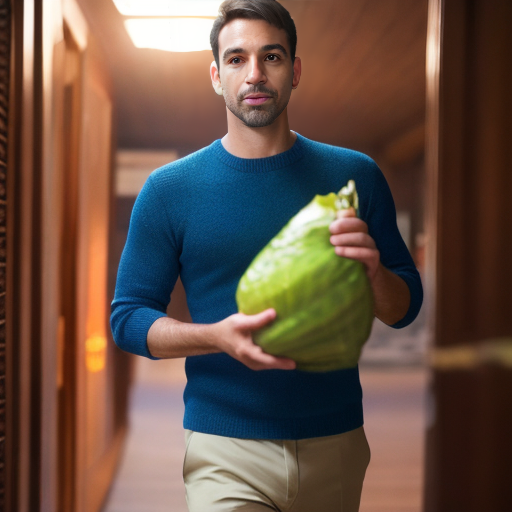

In [37]:
from PIL import Image
# B, G, R => R, G, B
Image.fromarray(outputs[0][:, :, [2, 1, 0]])

In [48]:
from modelscope.outputs import OutputKeys


In [39]:
sample = Image.open(BASE_DIR / "not_mo_salah.webp")

In [69]:
face_img_path = BASE_DIR / "datasets/celebrities/mo_salah/faces/face1.jpg"
face_img = Image.open(face_img_path).convert('RGB')
# skin retoucing
result = gen_portrait.skin_retouching(face_img)
face_img = Image.fromarray(result[OutputKeys.OUTPUT_IMG][:,:,::-1])
# input_img

In [74]:
result = gen_portrait.image_face_fusion(dict(template=sample, user=face_img))[OutputKeys.OUTPUT_IMG]

2025-06-19 03:53:40,789 - modelscope - INFO - model inference done


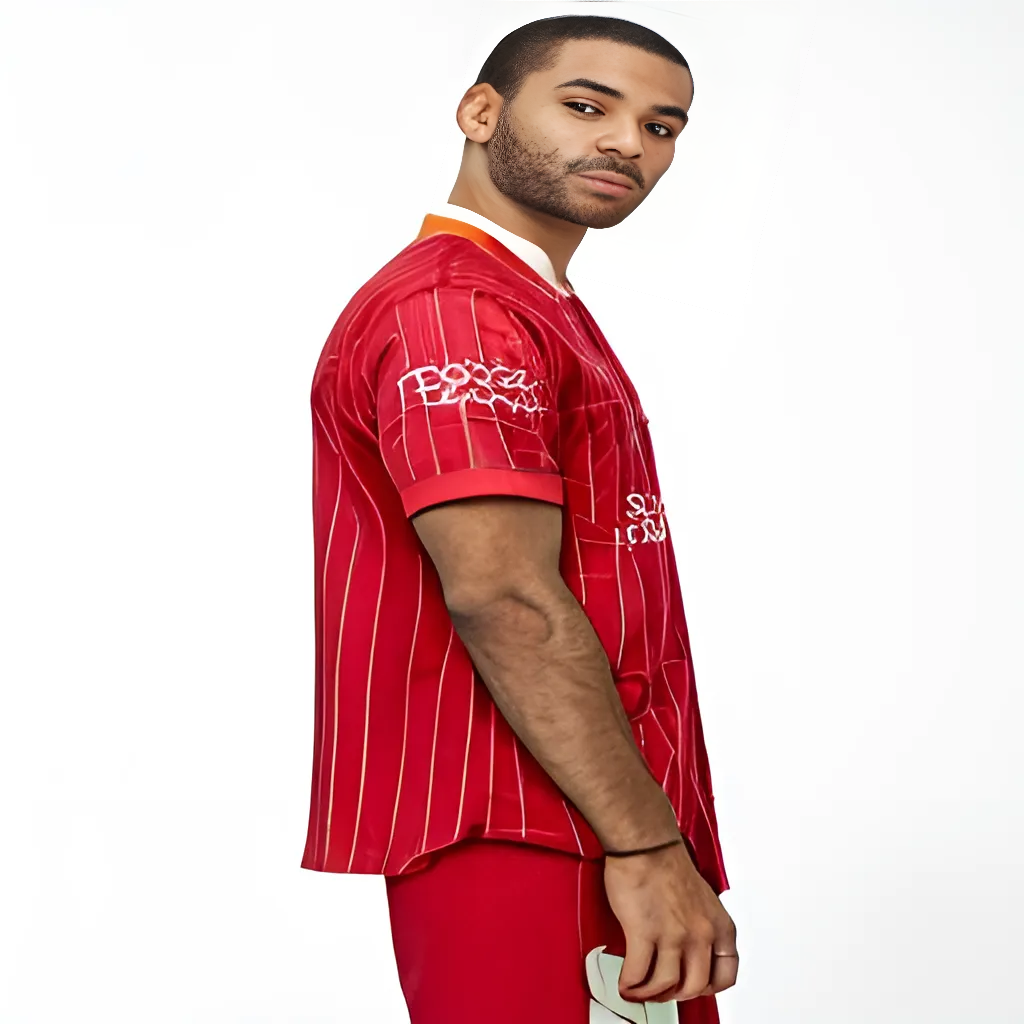

In [75]:
Image.fromarray(result[:,:,::-1])

In [76]:
from diffusers import StableDiffusionControlNetImg2ImgPipeline

In [84]:
pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    '/mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic',
    safety_checker=None,
    controlnet=gen_portrait.controlnet,
    torch_dtype=torch.float16)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /mnt/workspace/.cache/modelscope/models/MAILAND/majicmixRealistic_v6/realistic/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion licen

In [ ]:
pipe.generate(
    prompt=""
)

In [80]:
!ls 

configuration.json  README.md  realistic


In [5]:
from facechain.inference_inpaint_fact import GenPortrait_inpaint


In [81]:
gen_portrait_inpaint = GenPortrait_inpaint(
    
)

NameError: name 'GenPortrait_inpaint' is not defined

In [7]:
num_faces = 1
selected_face = 1
strength = 0.6
inpaint_img_path = str(BASE_DIR  / 'datasets/celebrities/mo_salah/cleaned/Frame 6.png')
input_img_path = str(BASE_DIR  / 'datasets/celebrities/mo_salah/cleaned/Frame 27.png')
num_generate = 1
output_dir = BASE_DIR / 'generated_inpaint'

pos_prompt = 'raw photo, masterpiece, simple background, solo, medium shot, high detail face, photorealistic, best quality, wearing T-shirt'
neg_prompt = 'nsfw, paintings, sketches, (worst quality:2), (low quality:2) ' \
                'lowers, normal quality, ((monochrome)), ((grayscale)), logo, word, character'
output_img_size = 512

In [8]:
outputs = gen_portrait(1, inpaint_img, strength, output_img_size, num_faces, selected_face, pos_prompt, neg_prompt, input_img_path, num_generate)

NameError: name 'gen_portrait' is not defined

In [37]:
from PIL import Image


# Load modules

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks

In [28]:
!ls -a /mnt/workspace/.cache/modelscope/models/yucheng1996/FaceChain-FACT

.  ..  FaceChain-FACT


In [32]:
modelscope_path = Path("/mnt/workspace/.cache/modelscope/models")
fact_model_path = modelscope_path / 'yucheng1996/FaceChain-FACT'

adapter_path = fact_model_path / 'adapter_maj_mask_large_new_reg001_faceshuffle_00290001.ckpt'
fr_weight_path = fact_model_path / 'ms1mv2_model_TransFace_S.pt'

In [33]:
face_detection = pipeline(
            task=Tasks.face_detection,
            model='damo/cv_ddsar_face-detection_iclr23-damofd',
            model_revision='v1.1')

2025-06-19 01:14:04,316 - modelscope - INFO - Use user-specified model revision: v1.1


2025-06-19 01:14:09,838 - modelscope - INFO - Use user-specified model revision: v1.1
2025-06-19 01:14:10,576 - modelscope - INFO - initiate model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
2025-06-19 01:14:10,577 - modelscope - INFO - initiate model from location /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd.
2025-06-19 01:14:10,580 - modelscope - INFO - initialize model from /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd
/opt/conda/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/opt/conda/lib/python3.8/site-pac

load checkpoint from local path: /mnt/workspace/.cache/modelscope/models/damo/cv_ddsar_face-detection_iclr23-damofd/pytorch_model.pt


2025-06-19 01:14:20,968 - modelscope - INFO - load model done


In [63]:
inpaint_img = Image.open(inpaint_img_path)
input_img = Image.open(input_img_path)
# should select largest areas # but I will handle one now 
face_box = bbox = np.array(face_detection(inpaint_img)['boxes'][0] ).astype(np.int16)
# create mask
inpaint_img_large = np.copy(np.array(inpaint_img)[:, :, ::-1])
mask_large = np.ones_like(inpaint_img_large)
mask_large1 = np.zeros_like(inpaint_img_large)
h, w, _ = inpaint_img_large.shape

inpaint_img_large[bbox[1]:bbox[3], bbox[0]:bbox[2]] = 0
mask_large[bbox[1]:bbox[3], bbox[0]:bbox[2]] = 0

In [49]:
# crop face image
face_ratio = 0.7
cropl = int(max(face_box[3] - face_box[1], face_box[2] - face_box[0]) / face_ratio / 2)
cx, cy = int((face_box[2] + face_box[0]) / 2), int((face_box[1] + face_box[3]) / 2)
cropup, cropbo, crople, cropri = min(cy, cropl), min(h - cy, cropl), min(cx, cropl), min(w - cx, cropl)

inpaint_img = np.pad(inpaint_img_large[cy - cropup:cy + cropbo, cx - crople:cx + cropri], 
                      ((cropl - cropup, cropl - cropbo), 
                       (cropl - crople, cropl - cropri), 
                       (0, 0)), 'constant')
inpaint_img = cv2.resize(inpaint_img, (512, 512))
inpaint_img = Image.fromarray(inpaint_img[:, :, ::-1])
mask_large1[cy - cropup:cy + cropbo, cx - crople:cx + cropri] = 1
mask_large = mask_large * mask_large1

In [78]:
input_img = Image.open(input_img_path).convert('RGB')
w, h = input_img.size
if max(w, h) > 2000:
    scale = 2000 / max(w, h)
    input_img = input_img.resize((int(w * scale), int(h * scale)))
input_img.size

(2000, 1416)

In [ ]:

segmentation_pipeline = pipeline(
            Tasks.image_segmentation,
            'damo/cv_resnet101_image-multiple-human-parsing',
            model_revision='v1.0.1')

image_face_fusion = pipeline('face_fusion_torch', model='damo/cv_unet_face_fusion_torch', model_revision='v1.0.3')

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
# with torch.no_grad():
    # outputs = gen_portrait_inpaint(1, inpaint_img, strength, output_img_size, num_faces, selected_face, pos_prompt, neg_prompt, input_img_path, num_generate)

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
